# NICER DATA VIEWER

Optics and Astronomical Technologies

University of Iowa

9 Dec 2025

Jacob Payne

In [14]:
import numpy as numpy
from astropy.io import fits
from astropy.table import Table, vstack
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from math import sqrt
from nicer_data_prep import read_xamin_table, get_evt_data, write_barycorr_sh, bulk_process

# Plot phase-o-gram

In [21]:
obsids = ['1070020301']
evt_data = get_evt_data(obsids[0])

In [22]:
evt_data

TIME,RAWX,RAWY,PHA,PHA_FAST,DET_ID,DEADTIME,EVENT_FLAGS,TICK,MPU_A_TEMP,MPU_UNDER_COUNT,PI_FAST,PI,PI_RATIO,BARYTIME,BARY_REF_TIME,PHASE
float64,uint8,uint8,int16,int16,uint8,float64,bool[8],int64,float64,int32,int16,int16,float32,float64,float64,float64
141954906.13597754,2,3,674,560,53,2.2637299999999998e-05,False .. False,102961277344556,31.03516096000004,4,103,114,1.1067961,141955250.66880307,-21691364.56919694,-0.4570007175207138
141954907.69813797,5,1,3597,3468,25,2.2637299999999998e-05,False .. False,102966490218359,33.47335485000002,3,1425,1464,1.0273684,141955252.23099026,-21691363.007009745,-0.6449527628719807
141954910.08548275,7,6,383,-32768,0,1.51949e-05,False .. False,102970175345023,32.201253690000044,5,-32768,21,nan,141955254.61837584,-21691360.619624168,-0.11477351561188698
141954910.56684497,0,5,723,703,63,2.2637299999999998e-05,False .. False,102958940061593,30.717135670000005,6,136,139,1.0220588,141955255.09974626,-21691360.13825375,-0.10951723903417587
141954913.13526583,7,0,387,-32768,6,1.51949e-05,False .. False,102970254040213,32.201253690000044,6,-32768,20,nan,141955257.6682108,-21691357.5697892,-0.3396356627345085
141954913.8853333,4,3,1204,1064,33,2.2637299999999998e-05,False .. False,102964847918963,34.10940543000004,11,280,298,1.0642858,141955258.41829103,-21691356.819708973,-0.8419693298637867
141954915.27324602,1,4,481,-32768,64,1.51949e-05,False .. False,102959061503043,30.61112724000003,4,-32768,55,nan,141955259.80622727,-21691355.43177274,-0.886528629809618
141954924.17917028,7,1,455,-32768,5,1.51949e-05,False .. False,102970539012003,32.30726212000002,7,-32768,38,nan,141955268.71230134,-21691346.52569866,-0.8262281082570553
141954925.6299334,1,0,491,-32768,47,1.51949e-05,False .. False,102963359266908,31.98923683000004,6,-32768,59,nan,141955270.16308868,-21691345.074911326,-0.5248946323990822


In [36]:
def make_phaseogram(evt_data, nbins=100):
    phases = evt_data['PHASE']
    phase_o_gram, bin_edges = np.histogram(phases, bins=nbins)
    return phase_o_gram

def normalize_phaseogram(phase_o_gram, norm = 'std'):
    if norm == 'std':
        mean_counts = np.mean(phase_o_gram)
        std_counts = np.std(phase_o_gram)
        normalized_phase_o_gram = (phase_o_gram - mean_counts) / std_counts
    elif norm == 'max':
        max_counts = np.max(phase_o_gram)
        normalized_phase_o_gram = phase_o_gram / max_counts
    elif norm == 'min':
        min_counts = np.min(phase_o_gram)
        normalized_phase_o_gram = phase_o_gram - min_counts
    return normalized_phase_o_gram


def plot_phaseogram(phase_o_gram, obsid_str):
    plt.plot(phase_o_gram, drawstyle='steps-mid', color='black')
    plt.ylim(-2, max(phase_o_gram)*1.1)
    plt.xlabel('Pulse Phase')
    plt.ylabel('Counts')
    plt.title(f'Phase-o-gram for Observation {obsid_str}')
    plt.show()
    return phase_o_gram


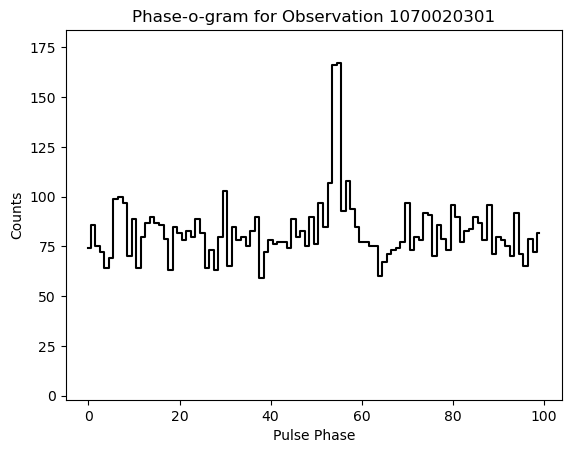

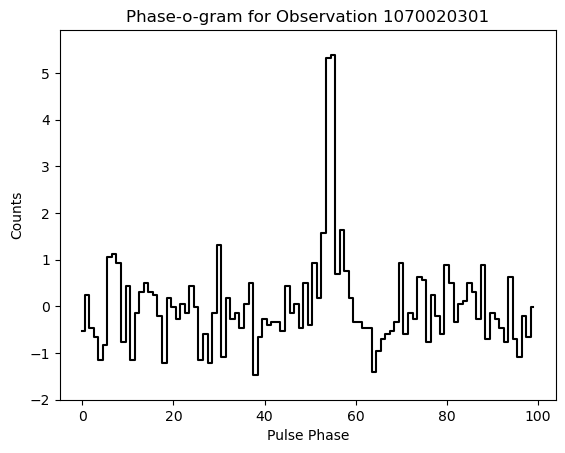

array([-0.51904598,  0.24239067, -0.45559293, -0.64595209, -1.15357652,
       -0.83631125,  1.06728037,  1.13073342,  0.94037426, -0.7728582 ,
        0.43274983, -1.15357652, -0.13832766,  0.30584372,  0.49620288,
        0.30584372,  0.24239067, -0.20178071, -1.21702958,  0.17893761,
       -0.01142155, -0.26523377,  0.0520315 , -0.13832766,  0.43274983,
       -0.01142155, -1.15357652, -0.58249904, -1.21702958, -0.13832766,
        1.32109258, -1.09012347,  0.17893761, -0.26523377, -0.13832766,
       -0.45559293,  0.0520315 ,  0.49620288, -1.47084179, -0.64595209,
       -0.26523377, -0.39213987, -0.32868682, -0.32868682, -0.51904598,
        0.43274983, -0.13832766,  0.0520315 , -0.45559293,  0.49620288,
       -0.39213987,  0.94037426,  0.17893761,  1.5749048 ,  5.31863499,
        5.38208804,  0.68656204,  1.63835785,  0.7500151 ,  0.17893761,
       -0.32868682, -0.32868682, -0.45559293, -0.45559293, -1.40738874,
       -0.96321736, -0.70940514, -0.58249904, -0.51904598, -0.32

In [37]:
phase_o_gram1 = make_phaseogram(evt_data)
plot_phaseogram(phase_o_gram1, obsids[0])
phase_o_gram1 = normalize_phaseogram(phase_o_gram1, norm='std')
plot_phaseogram(phase_o_gram1, obsids[0])

In [ ]:
bulk_download = read_xamin_table('xamin_b1937+21_exp10000.csv')
print(f'Found {len(bulk_download)} obsids in xamin table')
# print(bulk_download)
bulk_download_sorted = sorted(bulk_download)
# print(bulk_download_sorted)
post_MAR2019_bulk_download = bulk_download_sorted[-16:]
print(f'Using the {len(post_MAR2019_bulk_download)} obsids after the PSR 1937+21 frequency_epoch')

# make subplots for each observation in a 2x8 grid
subplot_rows = 4
subplot_cols = 4    
fig, axs = plt.subplots(subplot_rows, subplot_cols, figsize=(15, 8))
fig.suptitle('Phase-o-grams for Each Observation', fontsize=16)
axs = axs.flatten()  # Flatten the 2D array of axes to 1D for easy iteration

for i in range(len(post_MAR2019_bulk_download)):
    print(f'Observation {i}: obsid {post_MAR2019_bulk_download[i]}')
    obsid = [post_MAR2019_bulk_download[i]]
    evt_data = get_evt_data(obsid[0])

    
    # Plot the phaseogram for each observation
    axs[i].plot(multi_phase_o_gram, drawstyle='steps-mid', color='black')
    axs[i].set_ylim(0, 1.2 * max(multi_phase_o_gram))
    # only label the x-axis on the bottom plots
    if i // subplot_cols == subplot_rows - 1:
        axs[i].set_xlabel('Phase')
    # only label the y-axis on the leftmost plots
    if i % subplot_cols == 0:
        axs[i].set_ylabel('Counts')
    axs[i].set_title(f"Obs {obsid[0]} \n {np.datetime64(np.datetime64('2014-01-01') + np.timedelta64(int(get_mission_time(obsid[0])), 's'),'D')}", fontsize=8)
    axs[i].tick_params(axis='both', which='major', labelsize=6)
    # add padding between subplots
    plt.subplots_adjust(hspace=0.5, wspace=0.4)
    # # delete the final subplot
    # if i == subplot_rows * subplot_cols - 2:
    #     fig.delaxes(axs[i+1])
    #     print('Deleted final unused subplot')